1 Этап. Загрузка данных (путь к ds + чтение)

In [46]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Настройки отображения
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

# Путь к скачанному архиву
DATA_PATH = Path("../data/raw/listings.csv.gz")

# Чтение архива напрямую
df = pd.read_csv(DATA_PATH, compression="gzip")

print(f"Строк: {df.shape[0]}, Колонок: {df.shape[1]}")
df.head(3)

Строк: 23144, Колонок: 90


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1192561049767674816,https://www.airbnb.com/rooms/1192561049767674816,20260630053230,2026-07-03,previous scrape,Studio apartment in Copenhagen!,Studio apartment in Vesterbro neighborhood. 10...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,122413415,https://www.airbnb.com/users/show/122413415,1.468241e+18,https://www.airbnb.com/users/profile/146824109...,Anna,NaN,9.0,3.0,9.0,3.0,"Copenhagen, Denmark",NaN,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/d56b9...,NaN,1.0,NaN,NaN,t,t,NaN,Vesterbro-Kongens Enghave,NaN,55.671814,12.550656,Entire condo,Entire home/apt,1,NaN,1 bath,1.0,NaN,"[""Kitchen"", ""Wifi""]","$1,159.00",2026-07-11,2026-07-12,1159.0,1159.0,"{""quote"": {""taxes"": null, ""currency"": ""DKK"", ""...",1,3,1,1,3,3,1.0,3.0,NaN,t,22,31,32,32,2026-07-03,13,6,0,32,6,36,41724.0,2024-08-07,2026-05-10,4.77,4.69,4.77,4.69,4.54,4.92,4.46,NaN,NaN,1,1,0,0,0.56
1,1448618670473676599,https://www.airbnb.com/rooms/1448618670473676599,20260630053230,2026-07-01,city scrape,120m² • 6 Guests • Free Bikes • Nørrebro/Nordvest,Welcome to our bright and newly renovated 4-ro...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,6255542,https://www.airbnb.com/users/show/6255542,1.462702e+18,https://www.airbnb.com/users/profile/146270183...,Emil,NaN,13.0,1.0,11.0,1.0,"Copenhagen, Denmark",Emil Hamer Boisen\nLiving in Copenhagen,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/6255542/profi...,NaN,1.0,NaN,NaN,t,t,NaN,Bispebjerg,NaN,55.705552,12.533194,Entire condo,Entire home/apt,6,2.0,2 baths,2.0,3.0,"[""Bathtub"", ""Cleaning products"", ""Hangers"", ""C...","$1,832.50",2026-07-23,2026-07-27,7330.0,1832.5,"{""quote"": {""taxes"": null, ""currency"": ""DKK"", ""...",2,365,2,4,365,365,2.1,365.0,NaN,t,7,7,7,7,2026-07-01,1,1,0,7,1,6,10995.0,2025-07-10,2025-07-10,5.00,5.00,5.00,5.00,5.00,5.00,5.00,NaN,NaN,1,1,0,0,0.08
2,1468213160712999671,https://www.airbnb.com/rooms/1468213160712999671,20260630053230,2026-06-30,city scrape,Modern waterfront apartment,Unwind in this spacious and peaceful waterfron...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,505783700,https://www.airbnb.com/users/show/505783700,1.468213e+18,https://www.airbnb.com/users/profile/146821316...,Jonas,NaN,3.0,3.0,3.0,3.0,NaN,NaN,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/User/...,NaN,1.0,NaN,NaN,t

2 Этап. Фильтрация данных (отбор ключевых колонок, очистка цен и булевых полей, инспекция аномальных значений)

In [47]:
# 2.1. Отбор ключевых колонок для бизнес-анализа и ML
copenhagen_features = [
    # Идентификаторы и категории
    "id",
    "name",
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    # Геоданные
    "latitude",
    "longitude",
    # Вместимость и комнатность
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms_text",
    # Финансы и бронирование
    "price",
    "minimum_nights",
    "maximum_nights",
    "instant_bookable",
    # Метрики хозяина
    "host_is_superhost",
    "host_listings_count",
    # Отзывы и рейтинги
    "number_of_reviews",
    "review_scores_rating",
    "reviews_per_month",
]

df_clean = df[copenhagen_features].copy()
print(f"Размер после отбора фичей: {df_clean.shape}")

Размер после отбора фичей: (23144, 20)


In [48]:
# 2.2.1. Очистка цены: убираем знаки валюты и запятые, кастим во float
df_clean["price"] = (
    df_clean["price"]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .astype(float)
)

# 2.2.2. Очистка булевых колонок ('t' -> True, 'f' -> False)
df_clean["host_is_superhost"] = df_clean["host_is_superhost"].map({"t": True, "f": False})
df_clean["instant_bookable"] = df_clean["instant_bookable"].map({"t": True, "f": False})

# 2.2.3. Извлечение количества ванных комнат из текста "1.5 baths" / "1 shared bath"
df_clean["bathrooms"] = (
    df_clean["bathrooms_text"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)
df_clean = df_clean.drop(columns=["bathrooms_text"])

In [49]:
#Инспекция аномальных значений
print("Базовая статистика цен:")
print(df_clean["price"].describe())

# Проверяем строки с нулевой или подозрительно высокой ценой
print(f"\nКоличество объявлений с ценой 0: {(df_clean['price'] == 0).sum()}")
print(f"99-й перцентиль цены: {df_clean['price'].quantile(0.99):.2f}")

Базовая статистика цен:
count    13860.000000
mean      1960.367923
std       1282.439971
min         45.160000
25%       1272.670000
50%       1689.000000
75%       2305.000000
max      42931.330000
Name: price, dtype: float64

Количество объявлений с ценой 0: 0
99-й перцентиль цены: 6368.35


Построение boxplot ("ящик с усами" / "диаграмма размаха") + столбчатая диграмма.
Медиана как разделитель объёма, делит всю площадь 50%/50%. Ровно половина всех сдаваемых квартир в Копенгагене (6930 объявлений) стоят дешевле 1689 DKK, а вторая половина — дороже.
Медиана устойчива (робастна) к выбросам (outliner), но не среднее арифм.

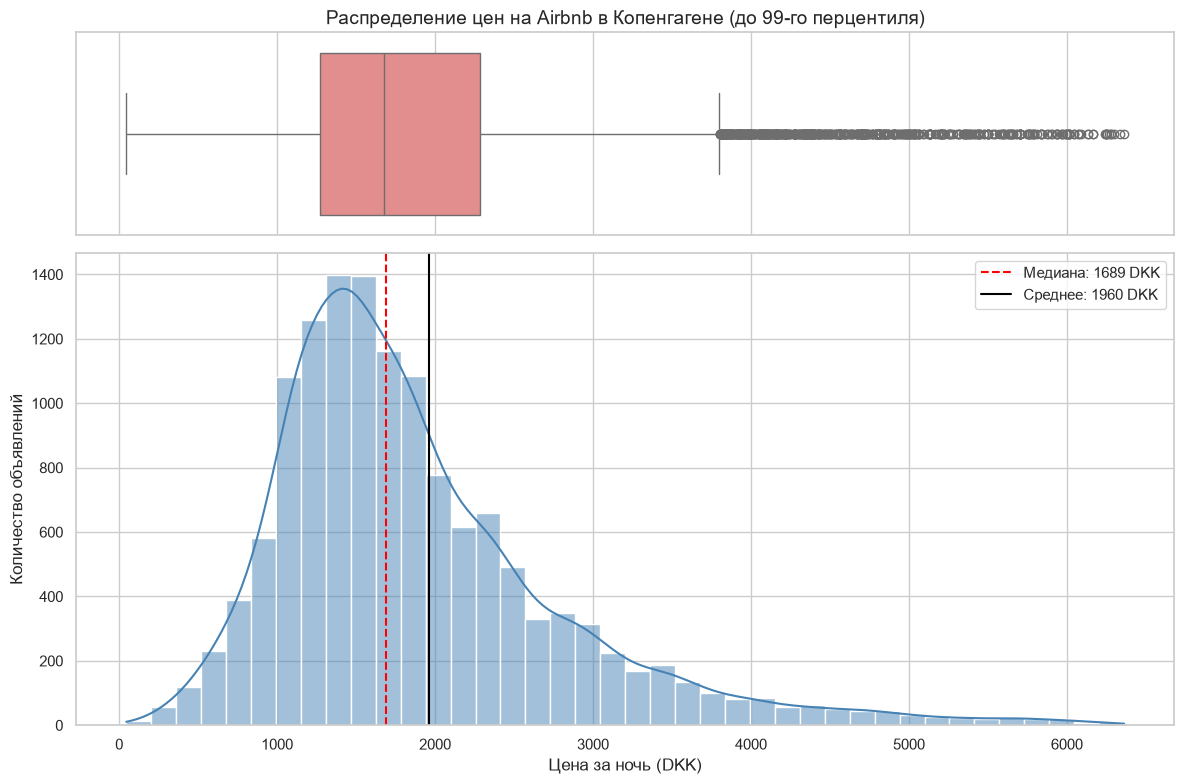

In [50]:
fig, (ax_box, ax_hist) = plt.subplots(
    nrows=2, 
    ncols=1, 
    figsize=(12, 8), 
    sharex=True, 
    gridspec_kw={"height_ratios": [0.3, 0.7]}
)

# Строим Boxplot цен (обрезав экстремальный 1% для читаемости графика)
p99 = df_clean["price"].quantile(0.99)
df_filtered_price = df_clean[df_clean["price"] <= p99]

sns.boxplot(data=df_filtered_price, x="price", ax=ax_box, color="lightcoral")
ax_box.set_title("Распределение цен на Airbnb в Копенгагене (до 99-го перцентиля)", fontsize=14)
ax_box.set_xlabel("")

# Строим гистограмму с KDE
sns.histplot(data=df_filtered_price, x="price", kde=True, ax=ax_hist, color="steelblue", bins=40)
ax_hist.set_xlabel("Цена за ночь (DKK)", fontsize=12)
ax_hist.set_ylabel("Количество объявлений", fontsize=12)

# Добавляем вертикальные линии для медианы и среднего
ax_hist.axvline(df_clean["price"].median(), color="red", linestyle="--", label=f"Медиана: {df_clean['price'].median():.0f} DKK")
ax_hist.axvline(df_clean["price"].mean(), color="black", linestyle="-", label=f"Среднее: {df_clean['price'].mean():.0f} DKK")
ax_hist.legend(fontsize=11)

fig.tight_layout()
fig.savefig("../figures/price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Инспекция пропусков (Missing Values)

In [51]:
# Анализируем пропуски по каждому столбцу
missing_summary = pd.DataFrame({
    "Пропусков (шт)": df_clean.isna().sum(),
    "Пропусков (%)": (df_clean.isna().mean() * 100).round(2)
})

# Показываем только столбцы, где есть хотя бы 1 пропуск, сортируя по убыванию
missing_summary = missing_summary[missing_summary["Пропусков (шт)"] > 0].sort_values(
    by="Пропусков (%)", ascending=False
)

print(f"Всего строк в датасете: {len(df_clean)}")
missing_summary

Всего строк в датасете: 23144


,Пропусков (шт),Пропусков (%)
instant_bookable,23144,100.00
beds,10482,45.29
price,9284,40.11
reviews_per_month,3060,13.22
review_scores_rating,3060,13.22
bedrooms,1487,6.42
bathrooms,204,0.88
host_is_superhost,1,0.00
host_listings_count,1,0.00


Анализ пропусков и выработка стратегии обработки (Engineering Decisions)

0. instant_bookable (100% пропусков) -> удаляем столбец
1. price (40.11% пропусков) -> удаляем только пустые строки

```Python
price (df.dropna(subset=['price'])
```
2. Для reviews_per_month -> заполняем 0 (0 отзывов в месяц).
3. Для review_scores_rating -> оставляем NaN или заполняем медианой при переходе к ML (создав флаг-индикатор отсутствия отзывов).
4. Если bedrooms не указан (часто это квартиры-студии) -> логично заполнить 1 или медианой в зависимости от room_type.
5. Если beds пропущен -> заполняем значением из столбца accommodates (число гостей) или медианой по типу жилья.
6. host_is_superhost и host_listings_count (всего 1 пропуск): Заполняем самым частым значением (модой) / медианой.

In [52]:
# 1. Удаляем полностью пустую колонку
df_clean = df_clean.drop(columns=["instant_bookable"])

# 2. Оставляем только строки с известной ценой
df_clean = df_clean.dropna(subset=["price"]).copy()

# 3. Обработка отзывов: нет отзывов -> 0 отзывов в месяц
df_clean["reviews_per_month"] = df_clean["reviews_per_month"].fillna(0.0)

# 4. Обработка вместимости и спальных мест
# Для студий/пропусков спален берем минимум 1
df_clean["bedrooms"] = df_clean["bedrooms"].fillna(1.0)

# Если кровати не указаны, приравниваем их к числу гостей (accommodates)
df_clean["beds"] = df_clean["beds"].fillna(df_clean["accommodates"])

# Ванные комнаты заполняем медианой (обычно 1.0)
df_clean["bathrooms"] = df_clean["bathrooms"].fillna(df_clean["bathrooms"].median())

# 5. Единичные пропуски в данных хоста
df_clean["host_is_superhost"] = df_clean["host_is_superhost"].fillna(False)
df_clean["host_listings_count"] = df_clean["host_listings_count"].fillna(1.0)

# Проверяем оставшиеся пропуски
print(f"Размер датасета после очистки: {df_clean.shape}")
print("\nОставшиеся пропуски:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

Размер датасета после очистки: (13860, 19)

Оставшиеся пропуски:
review_scores_rating    2072
dtype: int64


Этап 5. Построение корреляций.

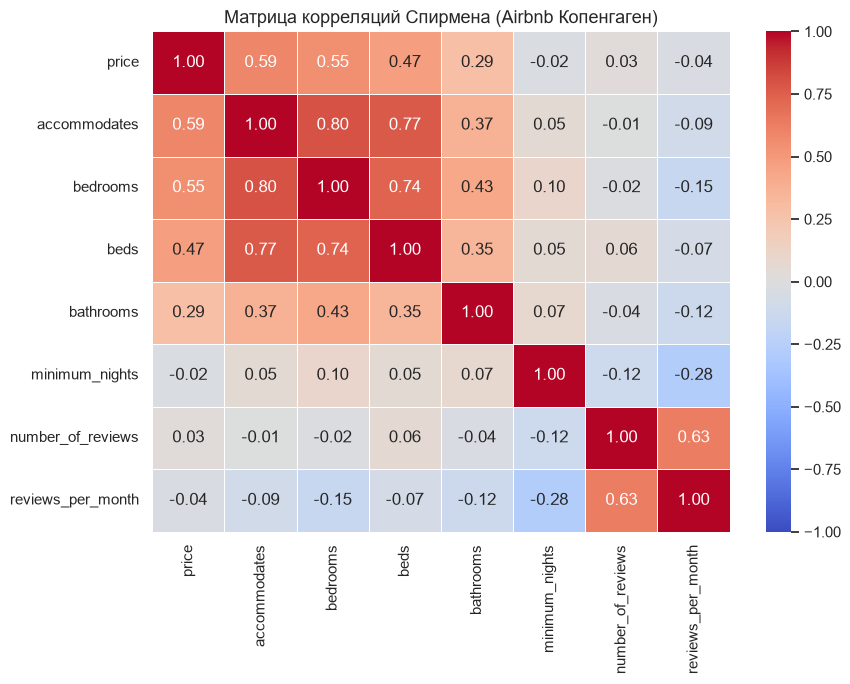

In [53]:
# Отбираем числовые столбцы для матрицы корреляций
numeric_cols = [
    "price", 
    "accommodates", 
    "bedrooms", 
    "beds", 
    "bathrooms", 
    "minimum_nights", 
    "number_of_reviews", 
    "reviews_per_month"
]

corr_spearman = df_clean[numeric_cols].corr(method="spearman")

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_spearman, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)
plt.title("Матрица корреляций Спирмена (Airbnb Копенгаген)", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

Анализ матрицы корреляций показывает:
1. accommodates (0.59) и bedrooms (0.55) — главные драйверы цены среди числовых признаков. Чем больше людей вмещает квартира и чем больше спален, тем выше стоимость аренды.
2. number_of_reviews (0.03) и reviews_per_month (-0.04) практически не влияют на цену напрямую.
3. Мультиколлинеарность между признаками:
 3.1. Квадраты 0.80 (accommodates vs bedrooms) и 0.77 (accommodates vs beds) во 2-й строке показывают взаимосвязь признаков между собой.
 3.2. Если два признака скоррелированы на уровне >= 0.8, они несут почти одинаковую информацию (квартира на 6 гостей неизбежно имеет больше комнат и кроватей).

Этап 6. 5 интересных инсайтов в виде графиков. [2/5]

C:\Users\Neradio\AppData\Local\Temp\ipykernel_1584\3087177321.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Neradio\AppData\Local\Temp\ipykernel_1584\3087177321.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


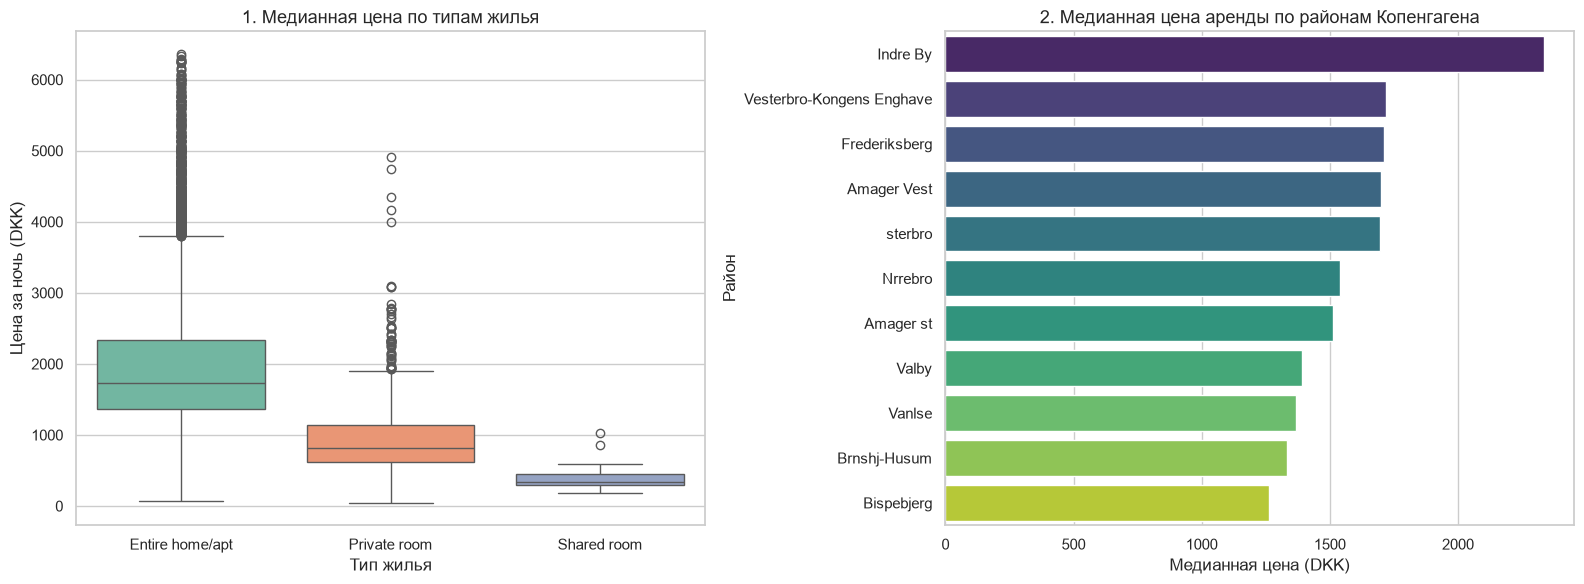

In [54]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Инсайт 1: Цена в зависимости от типа жилья (room_type)
sns.boxplot(
    data=df_clean[df_clean["price"] <= df_clean["price"].quantile(0.99)],
    x="room_type",
    y="price",
    palette="Set2",
    ax=ax1,
)
ax1.set_title("1. Медианная цена по типам жилья", fontsize=13)
ax1.set_xlabel("Тип жилья")
ax1.set_ylabel("Цена за ночь (DKK)")

# Инсайт 2: Топ-5 самых дорогих и дешевых районов (neighbourhood_cleansed)
top_neighbourhoods = (
    df_clean.groupby("neighbourhood_cleansed")["price"]
    .median()
    .sort_values(ascending=False)
)

sns.barplot(
    x=top_neighbourhoods.values,
    y=top_neighbourhoods.index,
    palette="viridis",
    ax=ax2,
)
ax2.set_title("2. Медианная цена аренды по районам Копенгагена", fontsize=13)
ax2.set_xlabel("Медианная цена (DKK)")
ax2.set_ylabel("Район")

fig.tight_layout()
fig.savefig("../figures/insights_1_2.png", dpi=300, bbox_inches="tight")
plt.show()

Инсайт 1 (Типы жилья)
 1. Медиана целой квартиры/дома (Entire home/apt) составляет около 1750 DKK, отдельной комнаты (Private room) — около 800 DKK, а общей комнаты (Shared room) — ~400 DKK.
 2. Сдача отдельного жилья целиком приносит в 2.2 раза больше дохода за ночь, чем аренда комнаты.

Инсайт 2 (География цены)
 1. Самый дорогой район Копенгагена с большим отрывом — исторический центр Indre By (медиана превышает 2300 DKK).
 2. Самые доступные районы — Bispebjerg и Brønshøj-Husum (медиана ~1250–1300 DKK).

Этап 6. 5 интересных инсайтов в виде графиков. [5/5]

C:\Users\Neradio\AppData\Local\Temp\ipykernel_1584\4125552022.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax3.set_xticklabels(("Обычный хозяин (False)", "Superhost (True)"))


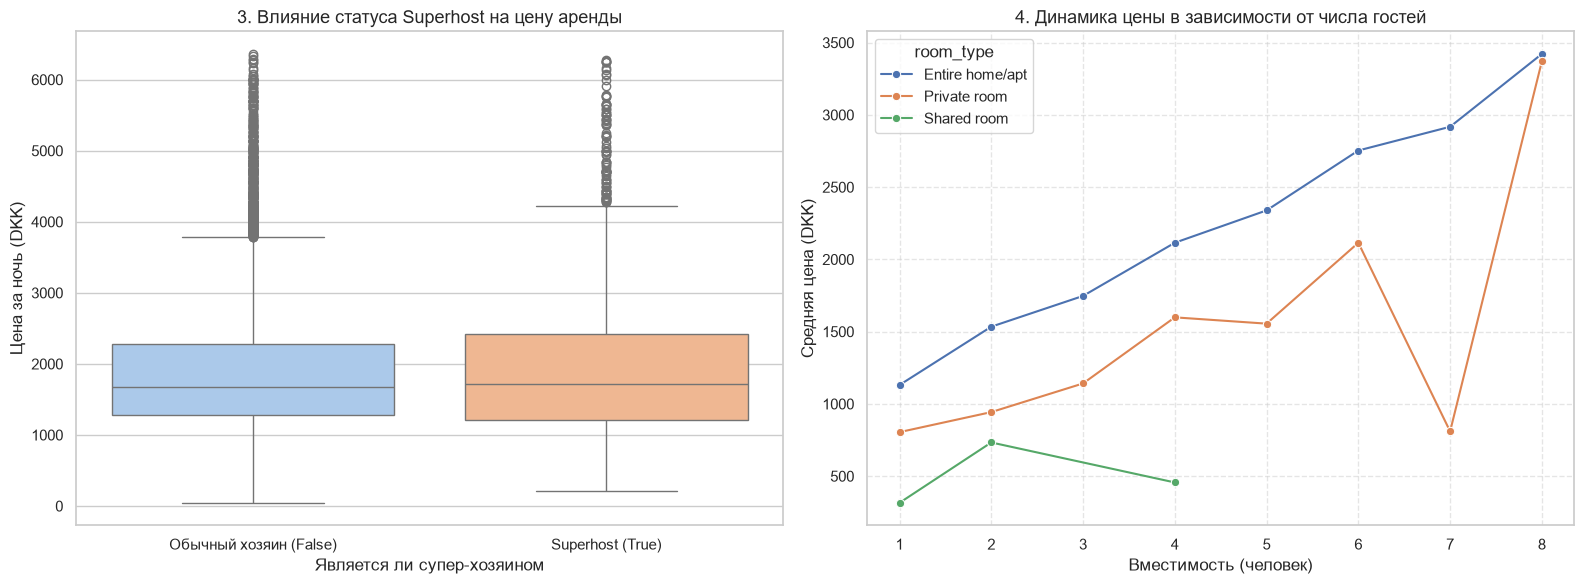

C:\Users\Neradio\AppData\Local\Temp\ipykernel_1584\4125552022.py:51: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig_map = px.scatter_mapbox(


In [ ]:
import plotly.express as px

# --- Статическая сетка 1x2 для Инсайтов 3 и 4 ---
fig, (ax3, ax4) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Фильтруем данные для адекватного отображения цен
p99 = df_clean["price"].quantile(0.99)
df_viz = df_clean[df_clean["price"] <= p99].copy()

# Инсайт 3: Влияние статуса Superhost на цену
df_viz["host_type"] = df_viz["host_is_superhost"].map(
    {True: "Superhost", False: "Обычный хост"}
)
sns.boxplot(
    data=df_viz,
    x="host_type",
    y="price",
    hue="host_type",
    order=["Обычный хост", "Superhost"],
    palette="pastel",
    legend=False,
    ax=ax3,
)
ax3.set_title("3. Влияние статуса Superhost на цену аренды", fontsize=13)
ax3.set_xlabel("Является ли супер-хозяином")
ax3.set_ylabel("Цена за ночь (DKK)")

# Инсайт 4: Зависимость цены от вместимости (accommodates) по типам жилья
# Ограничиваем вместимость до 8 гостей для исключения редких гигантских групп
sns.lineplot(
    data=df_viz[df_viz["accommodates"] <= 8],
    x="accommodates",
    y="price",
    hue="room_type",
    marker="o",
    errorbar=None,
    ax=ax4,
)
ax4.set_title("4. Динамика цены в зависимости от числа гостей", fontsize=13)
ax4.set_xlabel("Вместимость (человек)")
ax4.set_ylabel("Средняя цена (DKK)")
ax4.grid(True, linestyle="--", alpha=0.5)

fig.tight_layout()

# Сохраняем графики для будущего README
fig.savefig("../figures/insights_3_4.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Инсайт 5: Интерактивная карта цен по координатам через Plotly ---
fig_map = px.scatter_mapbox(
    df_viz.sample(
        min(3000, len(df_viz)), random_state=42
    ),  # сэмплируем для быстродействия
    lat="latitude",
    lon="longitude",
    color="price",
    size="accommodates",
    color_continuous_scale="Viridis",
    range_color=[df_viz["price"].min(), p99],
    hover_name="name",
    hover_data=["neighbourhood_cleansed", "room_type", "price"],
    zoom=10.5,
    title="5. Географическая карта распределения цен в Копенгагене",
    mapbox_style="carto-positron",
)

fig_map.write_html("../figures/copenhagen_map.html")
fig_map.show()

Все 5 инсайтов:
 1. Тип жилья: Entire home/apt в 2+ раза дороже комнат.
 2. География: Indre By — самый дорогой район, Bispebjerg — самый бюджетный.
 3. Superhost: статус не даёт права сильно завышать цену (конкуренция держит медианы близко), но обеспечивает стабильный поток бронирований.
 4. Вместимость: цена растёт квазилинейно с числом гостей для целых квартир.
 5. Гео-кластеризация: концентрация премиального сегмента вдоль центральной гавани.

Этап 7. Формирование финального README.md